# Dataset Exploration
Analyzes the YOLO-formatted SAR dataset: statistics, distributions, and sample visualizations.

In [1]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
from collections import Counter

DATA_DIR = Path('../../data') 
SPLITS = ['train', 'val', 'test']

## 1. Dataset Statistics

In [2]:
stats = {}
for split in SPLITS:
    img_dir = DATA_DIR / split / 'images'
    lbl_dir = DATA_DIR / split / 'labels'
    images = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')) if img_dir.exists() else []
    labels = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
    n_boxes = sum(len(l.read_text().splitlines()) for l in labels)
    size_mb = sum(p.stat().st_size for p in images) / 1e6
    stats[split] = {'images': len(images), 'labels': len(labels), 'boxes': n_boxes, 'size_mb': round(size_mb, 1)}

print(f"{'Split':<8} {'Images':>8} {'Labels':>8} {'Boxes':>8} {'Size (MB)':>10}")
print('-' * 46)
for split, s in stats.items():
    print(f"{split:<8} {s['images']:>8} {s['labels']:>8} {s['boxes']:>8} {s['size_mb']:>10}")
print(f"\nTotal images: {sum(s['images'] for s in stats.values())}")

Split      Images   Labels    Boxes  Size (MB)
----------------------------------------------
train           0        0        0        0.0
val             0        0        0        0.0
test            0        0        0        0.0

Total images: 0


## 2. Images per Actor per Split

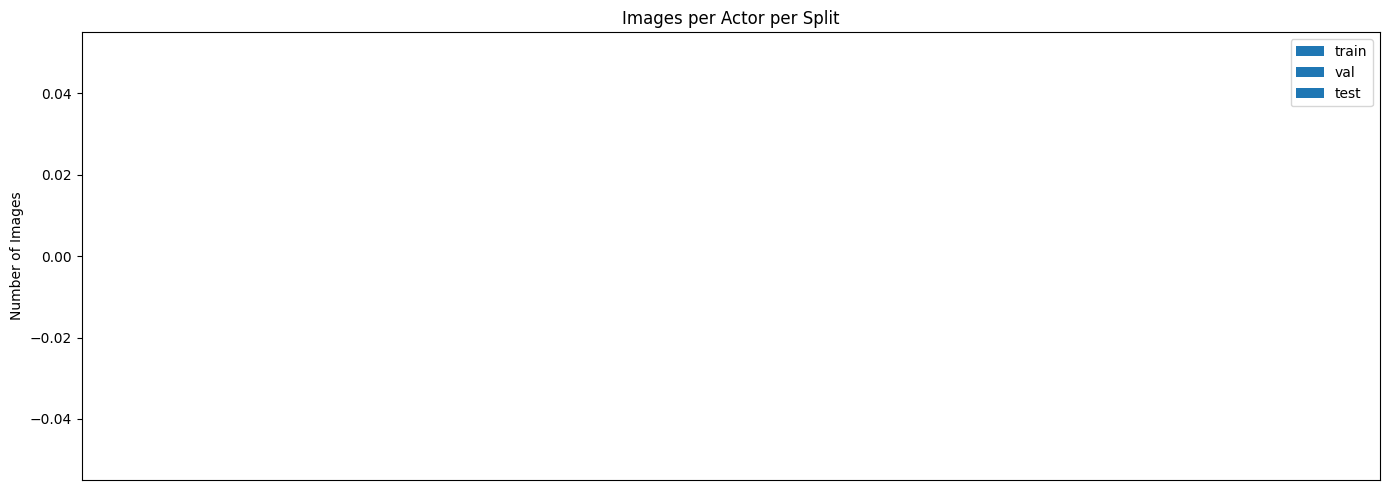

In [3]:
actor_counts = {split: Counter() for split in SPLITS}
for split in SPLITS:
    img_dir = DATA_DIR / split / 'images'
    if not img_dir.exists(): continue
    for p in img_dir.glob('*.jpg'):
        actor_counts[split][p.name.split('_')[0]] += 1

all_actors = sorted(set(a for c in actor_counts.values() for a in c))
x = np.arange(len(all_actors))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
for i, split in enumerate(SPLITS):
    ax.bar(x + i * width, [actor_counts[split].get(a, 0) for a in all_actors], width, label=split)
ax.set_xticks(x + width)
ax.set_xticklabels(all_actors, rotation=45, ha='right')
ax.set_ylabel('Number of Images')
ax.set_title('Images per Actor per Split')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Images per Angle per Split

In [ ]:
angle_counts = {split: Counter() for split in SPLITS}
for split in SPLITS:
    img_dir = DATA_DIR / split / 'images'
    if not img_dir.exists(): continue
    for p in img_dir.glob('*.jpg'):
        angle_counts[split][p.name.split('_')[1]] += 1

all_angles = sorted(set(a for c in angle_counts.values() for a in c))
x = np.arange(len(all_angles))

fig, ax = plt.subplots(figsize=(8, 4))
for i, split in enumerate(SPLITS):
    ax.bar(x + i * width, [angle_counts[split].get(a, 0) for a in all_angles], width, label=split)
ax.set_xticks(x + width)
ax.set_xticklabels(all_angles)
ax.set_ylabel('Number of Images')
ax.set_title('Images per Angle per Split')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Bounding Box Size Distribution

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, SPLITS):
    lbl_dir = DATA_DIR / split / 'labels'
    if not lbl_dir.exists(): continue
    widths, heights = [], []
    for lbl in lbl_dir.glob('*.txt'):
        for line in lbl.read_text().splitlines():
            parts = line.split()
            if len(parts) == 5:
                widths.append(float(parts[3]))
                heights.append(float(parts[4]))
    ax.scatter(widths, heights, alpha=0.1, s=2)
    ax.set_xlabel('Normalized Width')
    ax.set_ylabel('Normalized Height')
    ax.set_title(f'{split} ({len(widths)} boxes)')
plt.suptitle('Bounding Box Size Distribution')
plt.tight_layout()
plt.show()

## 5. Sample Images with Bounding Boxes (3 per split)

In [ ]:
def draw_sample(ax, img_path, lbl_path):
    img = Image.open(img_path)
    W, H = img.size
    ax.imshow(img)
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            parts = line.split()
            if len(parts) != 5: continue
            _, cx, cy, w, h = map(float, parts)
            ax.add_patch(patches.Rectangle(
                ((cx - w/2) * W, (cy - h/2) * H), w * W, h * H,
                linewidth=2, edgecolor='lime', facecolor='none'))
    ax.set_title(img_path.name, fontsize=7)
    ax.axis('off')

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for row, split in enumerate(SPLITS):
    img_dir = DATA_DIR / split / 'images'
    lbl_dir = DATA_DIR / split / 'labels'
    images = list(img_dir.glob('*.jpg')) if img_dir.exists() else []
    for col, img_path in enumerate(random.sample(images, min(3, len(images)))):
        draw_sample(axes[row][col], img_path, lbl_dir / (img_path.stem + '.txt'))
    axes[row][0].set_ylabel(split, fontsize=12, rotation=0, labelpad=60, va='center')

plt.suptitle('Random Samples with Bounding Boxes', fontsize=14)
plt.tight_layout()
plt.show()